## US Medical Insurance Costs
In this project I will be using some python fundamentals to perform a rudimentary analysis of the attributes within *insurance.csv*

To begin, I import the necessary libraries and inspect the data. 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
insurance_data = pd.read_csv('insurance.csv')
print(insurance_data.shape)
insurance_data.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#### With the limited data I have at hand, I think it would be interesting to explore any regional variation in smoking status and compare the average regional insurance premiums.

I begin my analysis by converting the *smoker* variable into a pair of binary dummy variables and grouping the data by region. 
After concatinating the data I calculated the proportion of smokers per region in the column *smoker_ratio*. I also summed the smoker and non-smokers per region in the column *population*, this was done just to ensure that the data was evenly distributed amongst regions. As we can see, there is a higher concentration of observations in the southeast than the other regions, which are a approximately even in their representation.

In [4]:
ins_data = pd.get_dummies(insurance_data['smoker']).astype(int)
ins_data = pd.concat([insurance_data, ins_data], axis=1).drop(columns=['smoker'])
ins_data = ins_data.rename(columns={'yes': 'smoker', 'no': 'non-smoker'})

ins_data.head()

,age,sex,bmi,children,region,charges,non-smoker,smoker
0,19,female,27.900,0,southwest,16884.92400,0,1
1,18,male,33.770,1,southeast,1725.55230,1,0
2,28,male,33.000,3,southeast,4449.46200,1,0
3,33,male,22.705,0,northwest,21984.47061,1,0
4,32,male,28.880,0,northwest,3866.85520,1,0


In [5]:
ins_region = ins_data.groupby('region').aggregate({'smoker': 'sum', 'non-smoker': 'sum', 'charges': 'mean'})
ins_region['smoker_ratio'] = ins_region['smoker'] / (ins_region['smoker'] + ins_region['non-smoker'])
ins_region['population'] = ins_region['smoker'] + ins_region['non-smoker']
ins_region.head()

,smoker,non-smoker,charges,smoker_ratio,population
region,,,,,
northeast,67,257,13406.384516,0.206790,324
northwest,58,267,12417.575374,0.178462,325
southeast,91,273,14735.411438,0.250000,364
southwest,58,267,12346.937377,0.178462,325


In [6]:
age = []
sex = []
bmi = []
children = []
smoker = []
charges = []

In [7]:
for index, row in insurance_data.iterrows():
    age.append(row['age'])
    sex.append(row['sex'])
    bmi.append(row['bmi'])
    children.append(row['children'])
    smoker.append(row['smoker'])
    charges.append(row['charges'])

In [8]:
avg_age = sum(age) / len(age)
avg_bmi = sum(bmi) / len(bmi)

#### Multiple Linear Regression

Just for fun, I am going to manually perform a multiple linear regression using *charges* as the response variable. 

In [128]:
design = pd.get_dummies(insurance_data['region']).astype(int)
design = pd.concat([insurance_data, design], axis=1).drop(columns=['region'])
smoke = pd.get_dummies(design['smoker']).astype(int).drop(columns=['no'])
design = pd.concat([design, smoke], axis=1).drop(columns=['smoker']).rename(columns={'yes': 'smoker'})    # 1 indicates smoker 
sex = pd.get_dummies(design['sex']).astype(int).drop(columns=['female'])
design = pd.concat([design, sex], axis=1).drop(columns=['sex']).rename(columns={'male': 'sex'})   # 1 indicates male

print(design.dtypes)

age            int64
bmi          float64
children       int64
charges      float64
northeast      int64
northwest      int64
southeast      int64
southwest      int64
smoker         int64
sex            int64
dtype: object


Building the design matrix $X$ and response vector $y$ to find the $\beta_i$ coefficients. To avoid the issue of multicollinearity, I dropped the *northeast* column from the data. If *northwest*=*southeast*=*southwest*=0, it indicates that the region of the corresponding observation is *northeast.*
  
  $\beta=(X^TX)^{-1}X^TY$

In [130]:
# Design matrix
X = design.drop(columns=['charges', 'northeast']) 
X = sm.add_constant(X)  # Add intercept term

# Response vector
y = design['charges']

# Beta coefficients
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("X Shape: ", X.shape)
print("Y Shape: ", y.shape)
print("Beta Shape: ", beta.shape)

X.head()

X Shape:  (1338, 9)
Y Shape:  (1338,)
Beta Shape:  (9,)


,const,age,bmi,children,northwest,southeast,southwest,smoker,sex
0,1.0,19,27.900,0,0,0,1,1,0
1,1.0,18,33.770,1,0,1,0,0,1
2,1.0,28,33.000,3,0,1,0,0,1
3,1.0,33,22.705,0,1,0,0,0,1
4,1.0,32,28.880,0,1,0,0,0,1


Next I analyze the structure of the model by plotting its residuals.  
    
This residual plot is far from perfect. The spread of the residuals appears to increase in unison with the fitted values. This is indicative of heteroskedastic variance. Additionally, there is a clear structure to the plot, as opposed to random scatter, suggesting that a linear model may not be the best choice. Perhaps a quadratic or cubic regression would yield better results.  
There is also likely some correlation effects occuring between predictors. Adding some interaction terms would probably be beneficial. A likely candidate would be $(age\cdot bmi)$, and perhaps $(age\cdot smoker)$.  

Text(0, 0.5, 'Residuals')

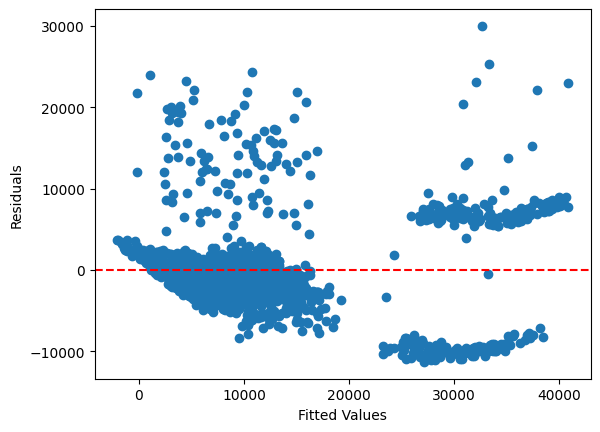

In [129]:
y_hat = X.to_numpy() @ beta
residuals = y - y_hat   

plt.scatter(y_hat, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')